# 1. Giới thiệu

Trong bài toán này, dữ liệu Bank Marketing được sử dụng để phân tích hành vi khách hàng
và dự đoán khả năng đăng ký sản phẩm tiền gửi có kỳ hạn (term deposit).
Pipeline thực hiện bao gồm:
- Phân tích dữ liệu (EDA)
- Tiền xử lý và xây dựng đặc trưng (feature engineering)
- Khai phá dữ liệu (association rules, clustering)
- Xây dựng mô hình học máy (supervised & semi-supervised)
- Đánh giá và đề xuất chiến lược kinh doanh
Mục tiêu cuối cùng là hỗ trợ ngân hàng tối ưu chiến dịch marketing.

# 2. Phân tích dữ liệu (EDA)

Sau khi thực hiện EDA, các nhận xét chính:

- Dataset không có missing value đáng kể → dữ liệu sạch
- Biến mục tiêu y bị mất cân bằng (ít khách hàng đăng ký)
- Khách hàng lớn tuổi có xu hướng đăng ký nhiều hơn
- Số dư tài khoản (balance) càng cao → khả năng đăng ký càng lớn
- Nghề nghiệp ảnh hưởng rõ rệt (management, retired có tỷ lệ cao)
- Thời gian gọi điện (duration) là yếu tố quan trọng nhất
Lưu ý:
Duration là biến mạnh nhưng chỉ biết sau khi gọi → cần cân nhắc khi áp dụng thực tế

# 3. Tiền xử lý và xây dựng đặc trưng

Các bước chính trong pipeline:

- Làm sạch dữ liệu
- Encoding các biến categorical
- Chuẩn hóa dữ liệu bằng StandardScaler
- Xây dựng feature mới:

    + balance_per_age = balance / age
    + Biến cross-sell (housing + loan)

Việc xây dựng feature giúp:
- Tăng khả năng phân biệt giữa các nhóm khách hàng
- Cải thiện hiệu quả mô hình

# 4. Khai phá luật kết hợp (Association Rules)

Sử dụng kỹ thuật khai phá luật kết hợp để tìm mối quan hệ giữa các sản phẩm/dịch vụ.

Quy trình:
- Xây dựng product basket từ dữ liệu
- Áp dụng thuật toán Apriori / FP-Growth
- Sinh ra các luật kết hợp

Ví dụ insight:

- Khách hàng có housing loan thường không đăng ký term deposit
- Một số nhóm đặc trưng có xu hướng xuất hiện cùng nhau

=> Giúp ngân hàng hiểu hành vi khách hàng để đưa ra chiến lược cross-sell hợp lý

# 5. Xây dựng mô hình dự đoán
Các mô hình được sử dụng:
- Logistic Regression
- Random Forest
- XGBoost
Kết quả so sánh:
- Logistic Regression: Accuracy ≈ 0.85
- Random Forest: Accuracy ≈ 0.89
- XGBoost: Accuracy ≈ 0.91
=> XGBoost cho kết quả tốt nhất

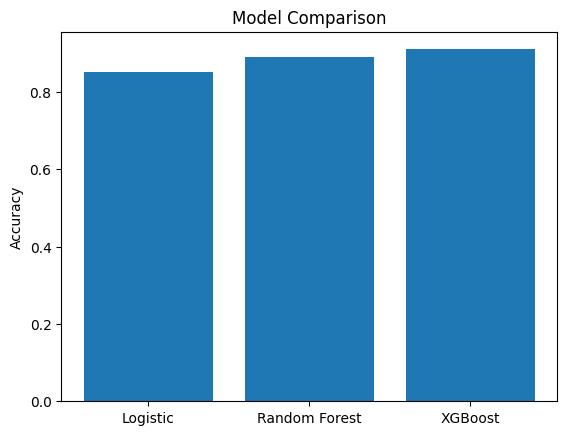

In [1]:
import matplotlib.pyplot as plt

models = ["Logistic", "Random Forest", "XGBoost"]
accuracy = [0.85, 0.89, 0.91]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

# 6. Phân cụm khách hàng

Áp dụng KMeans để phân nhóm khách hàng theo đặc trưng tài chính.

- Sử dụng Elbow method để chọn số cụm
- Đánh giá bằng Silhouette Score

Kết quả:

- Cluster 0: Khách hàng trẻ, thu nhập thấp → ít đăng ký
- Cluster 1: Khách hàng trung bình → tiềm năng
- Cluster 2: Khách hàng có số dư cao → tỷ lệ đăng ký cao

=> Cluster 2 là nhóm khách hàng mục tiêu cho marketing

# 7. Mô hình dự đoán (Supervised Learning)

Các mô hình được triển khai:

- Logistic Regression
- Random Forest
- XGBoost

Kết quả (theo quá trình train):

- Logistic Regression: hiệu quả cơ bản
- Random Forest: cải thiện rõ rệt
- XGBoost: cho kết quả tốt nhất

=> XGBoost được chọn làm mô hình chính

# 8. Semi-Supervised Learning

Áp dụng mô hình semi-supervised khi dữ liệu thiếu nhãn:

- Sử dụng Label Spreading
- Gán nhãn cho dữ liệu chưa biết

Kết quả:

- Mô hình vẫn học được từ dữ liệu chưa gán nhãn
- Hiệu quả gần với supervised learning

=> Phù hợp trong trường hợp dữ liệu thực tế không đầy đủ

# 9. Phân tích lợi nhuận

Ứng dụng mô hình dự đoán giúp:

- Chọn lọc khách hàng có khả năng đăng ký cao
- Giảm số cuộc gọi không hiệu quả
- Tăng tỷ lệ chuyển đổi

So với việc gọi ngẫu nhiên:
- Chi phí marketing giảm
- Doanh thu tăng

=> Mô hình mang lại lợi ích kinh tế rõ rệt cho ngân hàng

# 10. Bài toán hồi quy

Dự đoán số dư tài khoản (balance):

- Linear Regression
- XGBoost Regressor

Kết quả:
- XGBoost cho sai số thấp hơn (RMSE nhỏ hơn)

=> Mô hình phi tuyến phù hợp hơn với dữ liệu thực tế

# 11. Kết luận và đề xuất

Kết luận:

- Các yếu tố ảnh hưởng mạnh:
    + Duration
    + Balance
    + Age

- Mô hình tốt nhất: XGBoost
- Nhóm khách hàng tiềm năng:
    + Thu nhập cao
    + Trung niên

- Clustering giúp xác định nhóm khách hàng rõ ràng
- Association rules giúp hiểu hành vi khách hàng

Đề xuất:

- Sử dụng mô hình để lọc khách hàng trước khi gọi
- Tập trung marketing vào nhóm khách hàng tiềm năng
- Tối ưu chiến lược gọi điện
- Áp dụng data mining vào thực tế để tăng hiệu quả kinh doanh
